### ✈️ Fase 1: Exploración y Limpieza

In [144]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [145]:
df_flight = pd.read_csv("files/Customer Flight Activity.csv")
df_flight.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
156873,354438,2017,10,0,0,0,0,0.0,0,0
67135,973609,2017,4,0,0,0,0,0.0,0,0
124473,430097,2017,8,7,0,7,609,60.0,0,0
60655,628618,2017,4,7,0,7,2842,284.0,0,0
225919,292957,2018,2,5,3,8,1000,108.0,0,0


In [146]:
#Hacemos descripciones basicas del primer dataframe
print("Las filas y columnas del dataframes de vuelos son", df_flight.shape)
print(df_flight.info())

Las filas y columnas del dataframes de vuelos son (405624, 10)
<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB
None


In [147]:
round(df_flight.describe(),2).T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.87,258935.29,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.50,0.50,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.50,3.45,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.12,5.23,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.03,2.08,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.15,6.52,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.88,1433.16,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.69,146.60,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.70,125.49,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.48,10.15,0.0,0.00,0.0,0.00,71.0


In [148]:
df_flight.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='str')

In [149]:
#Como hay que explorar informacion por columnas, hacemos una funcion para poder revisar si hay nulos y gestionarlos. 
def gestion_nulos(df):
    """
    Función para identificar valores nulos por columna en un DataFrame.
    """
    print(f"{'COLUMNA':<25} | {'NULOS':<10} | {'PORCENTAJE'}")
    print("-" * 50)
    
    # Iteramos directamente sobre la lista de columnas del DataFrame
    for columna in df.columns:
        nulos = df[columna].isnull().sum()
        total = len(df)
        porcentaje = (nulos / total) * 100
        
        # Imprimimos de forma formateada para que todo quede alineado
        print(f"{columna:<25} | {nulos:<10} | {porcentaje:.2f}%")

In [150]:
#Llamamos a la funcion para el primer dataframe

gestion_nulos(df_flight)

COLUMNA                   | NULOS      | PORCENTAJE
--------------------------------------------------
Loyalty Number            | 0          | 0.00%
Year                      | 0          | 0.00%
Month                     | 0          | 0.00%
Flights Booked            | 0          | 0.00%
Flights with Companions   | 0          | 0.00%
Total Flights             | 0          | 0.00%
Distance                  | 0          | 0.00%
Points Accumulated        | 0          | 0.00%
Points Redeemed           | 0          | 0.00%
Dollar Cost Points Redeemed | 0          | 0.00%


### ✈️ EDA Datos: DataFrame de Vuelos

El dataframe de vuelos cuenta con **9 columnas** con la siguiente información:

* **Loyalty Number**: Identificador único para cada cliente dentro del programa de lealtad. Cada número corresponde a un cliente específico.
* **Year**: Año en el que se registraron las actividades de vuelo.
* **Month**: Mes del año (1 a 12) de la actividad de vuelo.
* **Flights Booked**: Número total de vuelos reservados por el cliente en ese mes específico.
* **Flights with Companions**: Número de vuelos reservados en los cuales el cliente viajó con acompañantes.
* **Total Flights**: Número total de vuelos realizados (puede incluir vuelos reservados en meses anteriores).
* **Distance**: Distancia total volada durante el mes (en millas o kilómetros).
* **Points Accumulated**: Puntos acumulados en el programa de lealtad durante el mes.
* **Points Redeemed**: Puntos que el cliente ha redimido (canjeado) en el mes para obtener beneficios.
* **Dollar Cost Points Redeemed**: Valor en dólares de los puntos redimidos durante el mes.

---

> **📌 Notas de Limpieza:**
> * No se detectan valores nulos.
> * Los tipos de datos son correctos.
> * La columna **Points Accumulated** se mantiene como `float` debido a la presencia de decimales.

In [151]:
#Ahora procederemos a explorar el segundo dataframe: 

df_loyalty = pd.read_csv("files/Customer Loyalty History.csv")
df_loyalty.sample(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1512,884089,Canada,Ontario,Toronto,M1R 4K3,Female,Master,111948.0,Married,Aurora,5926.73,Standard,2013,6,NaN,NaN
15988,373321,Canada,Ontario,Toronto,M8Y 4K8,Female,Doctor,65018.0,Married,Star,13466.92,Standard,2018,11,NaN,NaN
10116,624216,Canada,Ontario,Toronto,M2M 7K8,Female,College,NaN,Single,Star,2310.88,Standard,2017,2,NaN,NaN
11259,574330,Canada,Quebec,Hull,J8Y 3Z5,Female,Bachelor,64968.0,Married,Star,2599.97,Standard,2014,8,NaN,NaN
7343,580472,Canada,Quebec,Montreal,H2Y 4R4,Female,Doctor,258663.0,Divorced,Nova,6747.52,Standard,2012,11,NaN,NaN


In [152]:
#Hacemos descripciones basicas del segundo dataframe
print("Las filas y columnas del dataframes de fidelidad son", df_loyalty.shape)
print(df_loyalty.info())

Las filas y columnas del dataframes de fidelidad son (16737, 16)
<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15 

In [153]:
round(df_loyalty.describe(),2).T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.88,258912.13,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.61,35008.30,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.90,6860.98,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.25,1.98,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.67,3.40,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.50,1.38,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.96,3.46,1.00,4.00,7.00,10.00,12.00


In [154]:
#usamos la misma funcion para detectar nulos en este dataframe
gestion_nulos(df_loyalty)

COLUMNA                   | NULOS      | PORCENTAJE
--------------------------------------------------
Loyalty Number            | 0          | 0.00%
Country                   | 0          | 0.00%
Province                  | 0          | 0.00%
City                      | 0          | 0.00%
Postal Code               | 0          | 0.00%
Gender                    | 0          | 0.00%
Education                 | 0          | 0.00%
Salary                    | 4238       | 25.32%
Marital Status            | 0          | 0.00%
Loyalty Card              | 0          | 0.00%
CLV                       | 0          | 0.00%
Enrollment Type           | 0          | 0.00%
Enrollment Year           | 0          | 0.00%
Enrollment Month          | 0          | 0.00%
Cancellation Year         | 14670      | 87.65%
Cancellation Month        | 14670      | 87.65%


### 💳👨‍👩‍👧‍👦 EDA Datos: DataFrame de Fidelidad  
El dataframe de fidelidad cuenta con **15 columnas** con la siguiente información:

* **Loyalty Number**: Identificador único del cliente dentro del programa de lealtad.
* **Country**: País de residencia.
* **Province**: Provincia o estado.
* **City**: Ciudad.
* **Postal Code**: Código postal.
* **Gender**: Género del cliente.
* **Education**: Nivel educativo alcanzado.
* **Salary**: Ingreso anual estimado.Tiene 25.32% de nulos
* **Marital Status**: Estado civil.
* **Loyalty Card**: Tipo de tarjeta de lealtad.
* **CLV (Customer Lifetime Value)**: Valor total estimado del cliente (Float).
* **Enrollment Type**: Tipo de inscripción.
* **Enrollment Year**: Año de inscripción.
* **Enrollment Month**: Mes de inscripción.
* **Cancellation Year**: Año de cancelación. 
    > **Nota:** 87% de nulos. Se recomienda descartar.
* **Cancellation Month**: Mes de cancelación.
    > **Nota:** 87% de nulos. Se recomienda descartar.


### 🙅 Gestión de Nulos  
Como el Dataframe de Vuelos no tiene nulos, procederemos a limpiar el dataframe de fidelización antes de unir ambas tablas. Las columnas que tienen nulos son: 
* **Cancellation Year**: Año de cancelación. 
    > **Nota:** 87% de nulos. Se recomienda descartar.
* **Cancellation Month**: Mes de cancelación.
    > **Nota:** 87% de nulos. Se recomienda descartar.
* **Salary**: Ingreso anual estimado.Tiene 25.32% de nulos

In [155]:
#Procederemos a eliminar las tablas de cancellation de nuestro dataframe ya que no aportan valor

df_loyalty = df_loyalty.drop(columns=['Cancellation Year', 'Cancellation Month'])

In [156]:
df_loyalty.columns
#Veo que ha funcionado sin el inplace

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month'],
      dtype='str')

In [157]:
#el siguiente paso sera ver la columna de salario. 
df_loyalty["Salary"].describe()
#Causa un poco de curiosidad como el valor min del describe es un valor negativo. 

count     12499.000000
mean      79245.609409
std       35008.297285
min      -58486.000000
25%       59246.500000
50%       73455.000000
75%       88517.500000
max      407228.000000
Name: Salary, dtype: float64

<Axes: xlabel='Salary', ylabel='Count'>

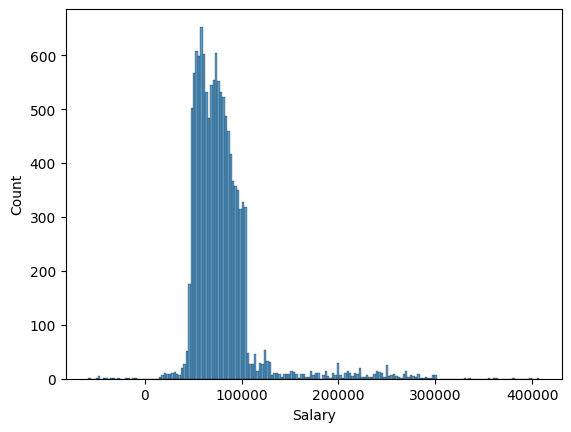

In [158]:
#Haremos un histograma para ver rapidamente como se comporta la columna e identificar
#la mejor manera de gestionar los nulos. al haber valores extremos a ambos lados y una desviacion estandar alta, la recomendacion es usar la mediana para gestionar nulos
sns.histplot(data=df_loyalty, x="Salary")

In [159]:
df_loyalty.loc[df_loyalty['Salary'].isnull()]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2
6,927943,Canada,Ontario,Toronto,P5S 6R4,Female,College,NaN,Single,Star,3857.95,Standard,2014,6
13,988178,Canada,Quebec,Montreal,H4G 3T4,Male,College,NaN,Single,Star,3871.07,Standard,2013,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16721,632951,Canada,Alberta,Edmonton,T9G 1W3,Female,College,NaN,Married,Star,44771.30,Standard,2018,7
16727,546773,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Married,Star,52811.49,Standard,2015,9
16731,900501,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,61134.68,Standard,2012,9
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12


In [160]:
mediana_salario = df_loyalty['Salary'].median()

In [161]:
#Luego de la inspeccion visual es evidente que faltan los datos de todos los que fueron al collegue. En este caso el imputer no seria la mejor opcion, sino reemplazar con la mediana. 
#Esto nos permitira tener los datos completos sin alterar la distribucion

df_loyalty["Salary"] = df_loyalty["Salary"].fillna(mediana_salario)


In [162]:
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73455.0,Divorced,Star,3839.61,Standard,2016,3
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73455.0,Single,Star,3839.75,Standard,2014,7
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73455.0,Single,Star,3839.75,Standard,2013,2
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10


In [163]:
#Ahora con cero nulos, procedemos a unir las tablas
df_loyalty.isna().sum()

Loyalty Number      0
Country             0
Province            0
City                0
Postal Code         0
Gender              0
Education           0
Salary              0
Marital Status      0
Loyalty Card        0
CLV                 0
Enrollment Type     0
Enrollment Year     0
Enrollment Month    0
dtype: int64

### 🧑‍🤝‍🧑Gestion de Duplicados
Como la columna Loyalty Number es la que vamos a usar para la gestion de duplicados, comprobamos que en en el dataframe de Loyalty no haya duplicados antes de hacer un merge

In [164]:
df_loyalty.duplicated(subset = "Loyalty Number").sum()

np.int64(0)

### Union de Dataframes
Se decide usar un left merge teniendo el dataframe de vuelos a la izquierda porque nos interesa conservar todas las coincidencias posibles de clientes reservando vuelos

In [165]:
df_merge = df_flight.merge( right=df_loyalty, how='left',
                        left_on='Loyalty Number', right_on='Loyalty Number')



In [166]:
df_merge.isna().sum()
#El nuevo dataframe no tiene datos nulos

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
Country                        0
Province                       0
City                           0
Postal Code                    0
Gender                         0
Education                      0
Salary                         0
Marital Status                 0
Loyalty Card                   0
CLV                            0
Enrollment Type                0
Enrollment Year                0
Enrollment Month               0
dtype: int64

In [167]:
# Hacemos una inspeccion profunda del dataframe para ver que modificaciones hay que hacer a las columnas
# Procederemos a resetear el indice, 
df_merge.sample(10)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
283558,797158,2018,5,2,2,4,1620,162.0,0,0,Canada,Ontario,Kingston,M9K 2P4,Male,Bachelor,77699.0,Married,Nova,2885.33,Standard,2013,12
7504,113316,2017,4,0,0,0,0,0.0,0,0,Canada,British Columbia,Whistler,V6T 1Y8,Male,Bachelor,60156.0,Single,Aurora,5282.54,Standard,2017,12
224079,333644,2018,2,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,93261.0,Married,Nova,8717.05,Standard,2018,11
238284,707698,2018,4,5,2,7,1855,199.8,0,0,Canada,Ontario,Kingston,M9K 2P4,Female,Bachelor,72365.0,Married,Star,5174.69,Standard,2014,8
87072,238556,2017,6,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,75827.0,Married,Nova,3939.01,Standard,2013,7
25378,552235,2017,2,0,0,0,0,0.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,College,73455.0,Single,Nova,9780.85,Standard,2015,7
345919,520428,2018,9,11,0,11,3322,332.0,0,0,Canada,Ontario,Toronto,P2T 6G3,Male,Bachelor,48337.0,Single,Star,8439.62,Standard,2016,7
282794,756543,2018,5,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Female,Bachelor,49065.0,Married,Star,4841.06,Standard,2016,12
254303,285636,2018,3,3,0,3,2805,302.4,0,0,Canada,British Columbia,Vancouver,V6E 3D9,Female,Bachelor,88055.0,Married,Star,2582.41,Standard,2017,7
201197,913866,2017,12,8,0,8,816,81.0,0,0,Canada,Nova Scotia,Halifax,B3J 9S2,Female,Bachelor,75318.0,Divorced,Star,9772.74,Standard,2016,5


In [168]:
df_merge.describe(include=str)

,Country,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
count,405624,405624,405624,405624,405624,405624,405624,405624,405624
unique,1,11,29,55,2,5,3,3,2
top,Canada,Ontario,Toronto,V6E 3D9,Female,Bachelor,Married,Star,Standard
freq,405624,130896,81096,21984,203640,253752,235800,184224,382200


Procedemos a explorar las variables categoricas para ver si hay algo que limpiar y obtener mayor información., Haremos una funcion para iterar por todas las columnas categóricas

In [169]:
lista_categoricas = [
    'Country', 'Province', 'City', 'Postal Code', 'Gender', 
    'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type']

In [170]:
for columna in lista_categoricas:
    print(f"--- Análisis de la columna: {columna} ---")
    print(df_merge[columna].value_counts())
    print("\n")

--- Análisis de la columna: Country ---
Country
Canada    405624
Name: count, dtype: int64


--- Análisis de la columna: Province ---
Province
Ontario                 130896
British Columbia        106848
Quebec                   79968
Alberta                  23400
Manitoba                 15984
New Brunswick            15432
Nova Scotia              12576
Saskatchewan              9936
Newfoundland              6312
Yukon                     2688
Prince Edward Island      1584
Name: count, dtype: int64


--- Análisis de la columna: City ---
City
Toronto           81096
Vancouver         62520
Montreal          49920
Winnipeg          15984
Whistler          14040
Halifax           12576
Ottawa            12312
Edmonton          11808
Quebec City       11760
Trenton           11760
Dawson Creek      10776
Fredericton       10344
Regina             9936
Kingston           9720
Tremblant          9600
Victoria           9504
Hull               8688
West Vancouver     7872
St. John's    

Luego de la exploracion procederemos a hacer dos últimos procedimientos,eliminar la columna Country, dado que todos los datos proceden de Canadá, por lo que no nos aporta valor en este momento

In [172]:
df_merge.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1


In [175]:
df_merge_final = df_merge.drop("Country", axis=1)

In [176]:
df_merge_final.head(1)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.2,Standard,2016,8


In [178]:
df_merge_final.sample(10)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
239242,465891,2018,4,3,3,6,1116,166.50,0,0,Quebec,Montreal,H2T 9K8,Male,Bachelor,82198.0,Married,Aurora,8657.97,Standard,2017,9
246759,900460,2018,4,13,3,16,3040,328.32,0,0,Saskatchewan,Regina,S6J 3G0,Male,Doctor,152955.0,Married,Star,3954.34,Standard,2016,2
101559,107487,2017,7,0,0,0,0,0.00,0,0,Quebec,Montreal,H2T 2J6,Male,Master,105487.0,Divorced,Nova,7805.31,Standard,2017,4
182266,802958,2017,11,0,0,0,0,0.00,0,0,Ontario,Ottawa,K1F 2R2,Female,Bachelor,54302.0,Married,Star,2772.84,Standard,2014,4
58008,208961,2018,7,15,4,19,4066,406.00,464,38,Quebec,Montreal,H2T 9K8,Female,College,73455.0,Married,Aurora,17793.61,2018 Promotion,2018,4
325701,345841,2018,8,17,0,17,1819,181.00,0,0,Quebec,Montreal,H2T 9K8,Female,Bachelor,77473.0,Married,Nova,5029.67,Standard,2016,3
321044,996152,2018,7,7,0,7,1456,145.00,0,0,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,49212.0,Married,Star,9706.38,Standard,2017,12
286861,728316,2017,8,9,0,9,1332,133.00,0,0,Ontario,Trenton,K8V 4B2,Female,Bachelor,65885.0,Married,Nova,3245.33,Standard,2017,1
52482,196202,2017,4,0,0,0,0,0.00,0,0,Quebec,Quebec City,G1B 3L5,Female,Bachelor,97241.0,Married,Aurora,7443.83,Standard,2017,8
243241,454471,2018,3,0,0,0,0,0.00,0,0,Ontario,Toronto,M1R 4K3,Female,High School or Below,74758.0,Married,Star,2451.75,Standard,2015,9


In [179]:
df_merge_final = df_merge_final.reset_index()

In [180]:
df_merge_final.head()

,index,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8
1,1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3
2,2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7
3,3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8
4,4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1


In [177]:
print("Las filas y columnas del dataframe final son", df_merge_final.shape)


Las filas y columnas del dataframe final son (405624, 22)


💽Finalizamos la fase de exploracion y limpieza de datos y guardamos el dataframe en un CSV. 

In [181]:
df_merge_final.to_csv('files/vuelos_clientes.csv', index=False)